# 03 — Portfolio Construction and Backtest

## Objective

The objective of this notebook is to transform the momentum ranking into an investable long-only strategy.

Each month:
- the top 30% stocks are selected based on the momentum ranking
- selected stocks receive equal weights
- the portfolio is invested during the following month to avoid look-ahead bias
- monthly portfolio returns are computed

The strategy is then compared to a passive benchmark: the FEZ ETF in a buy-and-hold approach.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

## 1. Loading the input data

We reload:
- the monthly stock returns (`monthly_returns.csv`)
- the monthly momentum ranking (`momentum_rank.csv`)




## 2. Aligning the dates

Both datasets must be perfectly aligned over time.
We keep only the dates that are common between:
- the monthly returns
- the momentum ranking

This avoids any inconsistencies when constructing the portfolio.

In [2]:
monthly_returns = pd.read_csv("../data/monthly_returns.csv", index_col=0, parse_dates=True)
momentum_rank = pd.read_csv("../data/momentum_rank.csv", index_col=0, parse_dates=True)

common_dates = monthly_returns.index.intersection(momentum_rank.index)

monthly_returns = monthly_returns.loc[common_dates]
momentum_rank = momentum_rank.loc[common_dates]

print("Shape monthly_returns:", monthly_returns.shape)
print("Shape momentum_rank:", momentum_rank.shape)
print("First common date:", common_dates.min())
print("Last common date:", common_dates.max())

Shape monthly_returns: (191, 24)
Shape momentum_rank: (191, 24)
First common date: 2010-02-28 00:00:00
Last common date: 2025-12-31 00:00:00


## 3. Portfolio selection rule
The strategy is **long-only**:
we only buy stocks with the highest momentum scores.
Chosen rule:
- universe of 24 stocks
- selection of the top 30% each month
- this corresponds to 7 stocks
- each selected stock receives an **equal weight**

Important point:
- the signal is observed at month *t*
- the portfolio is actually invested at month *t+1*




## 4. Construction of monthly weights
For each month:
- a stock is selected if its momentum rank is less than or equal to `top_n`
- non-selected stocks receive a weight of zero
- selected stocks receive an equal weight

Thus, the portfolio is rebalanced each month in a simple and transparent way.


In [3]:
n_stocks = monthly_returns.shape[1]
top_n = int(np.floor(0.30 * n_stocks))

print("Number of stocks in universe:", n_stocks)
print("Number of selected stocks each month:", top_n)


# 1 si le stock est dans le top_n 0 sinon
selected = (momentum_rank <= top_n).astype(int)

weights = selected.div(selected.sum(axis=1), axis=0)
shifted_weights = weights.shift(1)

print("Signal weights (time t):")
print(weights.head(15))

print("\nInvested weights (actually used during the month):")
print(shifted_weights.head(15))

print("\nSum of invested portfolio weights by month:")
print(shifted_weights.sum(axis=1).head(15))

Number of stocks in universe: 24
Number of selected stocks each month: 7
Signal weights (time t):
            AD.AS    AIR.PA  ALV.DE   ASML.AS    BAS.DE  BBVA.MC  BNP.PA  \
Date                                                                       
2010-02-28    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-03-31    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-04-30    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-05-31    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-06-30    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-07-31    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-08-31    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-09-30    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-10-31    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-11-30    NaN       NaN     NaN       NaN       NaN      NaN  

## 5. Tickers Actually Held Each Month
To make the strategy interpretable, we display the stocks actually held during each month.
Since the portfolio invested at month t is based on the signal observed at month t-1,
the selected tickers must also be shifted by one month.

Therefore, each row of the table shows:
- the tickers actually held during that month
- the same positions used to compute the strategy return for that month

In [4]:
selected_shifted = selected.shift(1)

selected_tickers_table = selected_shifted.apply(lambda row: ", ".join(row.index[row == 1].tolist()),axis=1)
selected_tickers_table = selected_tickers_table.to_frame(name="Selected Tickers")

print(selected_tickers_table.head(15))

sample_date = selected_tickers_table.index[15]

print("\nSample date:", sample_date)
print("Tickers actually held during the month:")
print(selected_tickers_table.loc[sample_date, "Selected Tickers"])

                                             Selected Tickers
Date                                                         
2010-02-28                                                   
2010-03-31                                                   
2010-04-30                                                   
2010-05-31                                                   
2010-06-30                                                   
2010-07-31                                                   
2010-08-31                                                   
2010-09-30                                                   
2010-10-31                                                   
2010-11-30                                                   
2010-12-31                                                   
2011-01-31                                                   
2011-02-28  AIR.PA, ASML.AS, BAS.DE, ITX.MC, MC.PA, SAP.DE...
2011-03-31  AIR.PA, ASML.AS, BAS.DE, ITX.MC, MC.PA, SAP.DE...
2011-04-

## 6. Calculation of the strategy’s monthly returns
The portfolio’s monthly return is the weighted sum
of the returns of the selected stocks.
Important point:
to avoid **look-ahead bias**, the weights observed in month `t`
are used to invest in month `t+1`.

In other words:
- the signal is computed at the end of a month
- the investment is implemented over the following month




## 7. Cumulative performance curve (Equity Curve)
Monthly returns are converted into a cumulative performance curve,
starting from a base of 100.
This allows us to visualize how the portfolio’s value evolves over time.


In [5]:
# Strategy monthly return:
# the invested weights during month t are applied to stock returns observed during month t
strategy_returns = (shifted_weights * monthly_returns).sum(axis=1)

# Remove periods where the invested portfolio is not yet available
strategy_returns = strategy_returns.dropna()

print(strategy_returns.head(15))
print("\nFirst valid strategy return date:", strategy_returns.index.min())



strategy_equity = 100 * (1 + strategy_returns).cumprod()
strategy_equity.head(15)

Date
2010-02-28    0.000000
2010-03-31    0.000000
2010-04-30    0.000000
2010-05-31    0.000000
2010-06-30    0.000000
2010-07-31    0.000000
2010-08-31    0.000000
2010-09-30    0.000000
2010-10-31    0.000000
2010-11-30    0.000000
2010-12-31    0.000000
2011-01-31    0.000000
2011-02-28    0.018539
2011-03-31    0.002503
2011-04-30    0.024099
dtype: float64

First valid strategy return date: 2010-02-28 00:00:00


Date
2010-02-28    100.000000
2010-03-31    100.000000
2010-04-30    100.000000
2010-05-31    100.000000
2010-06-30    100.000000
2010-07-31    100.000000
2010-08-31    100.000000
2010-09-30    100.000000
2010-10-31    100.000000
2010-11-30    100.000000
2010-12-31    100.000000
2011-01-31    100.000000
2011-02-28    101.853853
2011-03-31    102.108810
2011-04-30    104.569557
dtype: float64

## 8. Benchmark: FEZ Buy-and-Hold
To evaluate the strategy, it must be compared to a market benchmark.
Here, we use **FEZ**, a U.S.-listed ETF that tracks
a broad basket of Eurozone equities.

Why FEZ ?
* it represents a simple and passive exposure to European equities
* it allows comparison with “buying the market” without factor selection
* it therefore serves as a natural benchmark for a European momentum strategy

The **buy-and-hold** approach means:
- buying FEZ at the beginning of the period
- making no active rebalancing
- simply observing its cumulative performance over time

The question is therefore:
**Does the momentum strategy outperform a passive exposure to European equities?**




## 9. Strategy vs. benchmark comparison

We now compare:
- the long-only momentum strategy
- the FEZ buy-and-hold benchmark

This comparison provides a first view of raw performance, before adding metrics, costs, and risk analysis.

[*********************100%***********************]  1 of 1 completed


Date
2010-02-28   -0.022169
2010-03-31    0.063880
2010-04-30   -0.057584
2010-05-31   -0.121113
2010-06-30   -0.026597
2010-07-31    0.151456
2010-08-31   -0.074432
2010-09-30    0.129022
2010-10-31    0.061836
2010-11-30   -0.126732
2010-12-31    0.089687
2011-01-31    0.084419
2011-02-28    0.025282
2011-03-31   -0.003944
2011-04-30    0.081552
Freq: ME, Name: FEZ, dtype: float64
First aligned date: 2010-02-28 00:00:00
Last aligned date: 2025-12-31 00:00:00


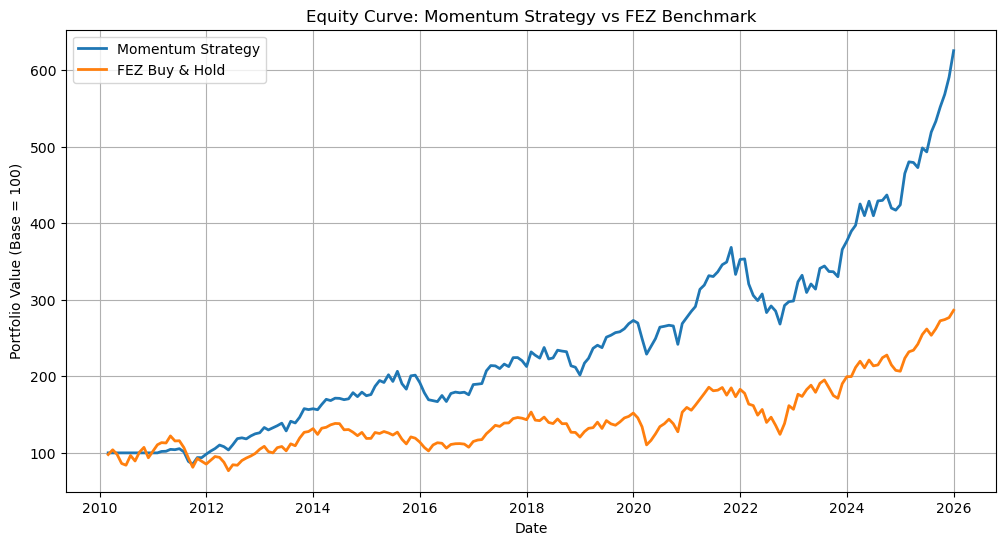

In [6]:
benchmark_data = yf.download("FEZ",start="2010-01-01",end="2025-12-31",auto_adjust=False,progress=True)
benchmark_prices = benchmark_data["Adj Close"].copy()
 
# Pour s'assurer que benchmark_prices est une Series
if isinstance(benchmark_prices, pd.DataFrame):
    benchmark_prices = benchmark_prices.iloc[:, 0]

benchmark_prices = benchmark_prices.sort_index().ffill()
benchmark_prices = benchmark_prices.resample("ME").last()
benchmark_returns = benchmark_prices.pct_change().dropna()
benchmark_equity = 100 * (1 + benchmark_returns).cumprod()
print(benchmark_returns.head(15))



common_index = strategy_returns.index.intersection(benchmark_returns.index)
strategy_returns_aligned = strategy_returns.loc[common_index]
strategy_equity_aligned = strategy_equity.loc[common_index]
benchmark_returns_aligned = benchmark_returns.loc[common_index]
benchmark_equity_aligned = benchmark_equity.loc[common_index]
selected_tickers_aligned = selected_tickers_table.loc[common_index]

# Convert 1-column DataFrames to Series if needed
if isinstance(strategy_returns_aligned, pd.DataFrame):
    strategy_returns_aligned = strategy_returns_aligned.iloc[:, 0]

if isinstance(strategy_equity_aligned, pd.DataFrame):
    strategy_equity_aligned = strategy_equity_aligned.iloc[:, 0]

if isinstance(benchmark_returns_aligned, pd.DataFrame):
    benchmark_returns_aligned = benchmark_returns_aligned.iloc[:, 0]

if isinstance(benchmark_equity_aligned, pd.DataFrame):
    benchmark_equity_aligned = benchmark_equity_aligned.iloc[:, 0]

print("First aligned date:", common_index.min())
print("Last aligned date:", common_index.max())



plt.figure(figsize=(12, 6))
plt.plot(strategy_equity_aligned, label="Momentum Strategy", linewidth=2)
plt.plot(benchmark_equity_aligned, label="FEZ Buy & Hold", linewidth=2)
plt.title("Equity Curve: Momentum Strategy vs FEZ Benchmark")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Base = 100)")
plt.legend()
plt.grid(True)
plt.show()

## 10. Save Monthly Backtest Summary
Instead of saving several separate CSV files, we build one consolidated monthly backtest summary table.
This table contains :
- FEZ monthly return
- FEZ cumulative value
- strategy monthly return
- strategy cumulative value
- tickers actually held during each month
This makes the results easier to read and reuse in the next notebooks.

In [7]:
backtest_summary = pd.DataFrame({"FEZ Return": benchmark_returns_aligned,"FEZ Equity": benchmark_equity_aligned,"Strategy Return": strategy_returns_aligned,"Strategy Equity": strategy_equity_aligned})

# Ajouter les tickers tenues pendant le mois
backtest_summary["Selected Tickers"] = selected_tickers_aligned["Selected Tickers"]

backtest_summary.to_csv("../data/backtest_summary.csv")

print("File saved successfully:")
print("- ../data/backtest_summary.csv")

backtest_summary.head(15)

File saved successfully:
- ../data/backtest_summary.csv


,FEZ Return,FEZ Equity,Strategy Return,Strategy Equity,Selected Tickers
Date,,,,,
2010-02-28,-0.022169,97.783101,0.000000,100.000000,
2010-03-31,0.063880,104.029442,0.000000,100.000000,
2010-04-30,-0.057584,98.039048,0.000000,100.000000,
2010-05-31,-0.121113,86.165268,0.000000,100.000000,
2010-06-30,-0.026597,83.873501,0.000000,100.000000,
2010-07-31,0.151456,96.576649,0.000000,100.000000,
2010-08-31,-0.074432,89.388262,0.000000,100.000000,
2010-09-30,0.129022,100.921314,0.000000,100.000000,
2010-10-31,0.061836,107.161918,0.000000,100.000000,


## Conclusion
In this notebook, the momentum signal was transformed into an investable portfolio:

- top 30% stocks were selected based on momentum ranking
- portfolio weights were built using equal weighting
- invested weights were shifted by one month to avoid look-ahead bias
- gross monthly strategy returns were computed
- the strategy was compared to a passive European benchmark, FEZ
- displayed tickers correspond to positions actually held during each month

This notebook provides the raw backtest foundation for the next steps:
performance metrics, risk analysis and transaction costs.

# Performance Metrics
## Objective
The objective of this section is to evaluate the momentum strategy quantitatively and compare it with the FEZ benchmark.

We use three standard performance metrics:
- CAGR, to measure annualized compounded performance
- annualized volatility, to measure risk
- Sharpe ratio, to measure risk-adjusted performance

These metrics complement the equity curve by providing a clearer view of return, risk and efficiency.

In [8]:
import sys
sys.path.append("src")
from metrics import cagr, annualized_volatility, sharpe_ratio

## 1. Load Backtest Summary

We reuse the consolidated backtest summary created previously.

It contains:
- monthly strategy returns
- strategy equity curve
- FEZ monthly returns
- FEZ equity curve
- tickers actually held each month


## 2. Extract Strategy and Benchmark Series

We extract the return and equity series required to compute performance metrics.

Returns are used for volatility and Sharpe ratio.
Equity curves are used for CAGR.

In [9]:
backtest_summary = pd.read_csv("../data/backtest_summary.csv", index_col=0, parse_dates=True)
backtest_summary.head()

strategy_returns = backtest_summary["Strategy Return"]
strategy_equity = backtest_summary["Strategy Equity"]

benchmark_returns = backtest_summary["FEZ Return"]
benchmark_equity = backtest_summary["FEZ Equity"]

## 3. CAGR — Compound Annual Growth Rate

CAGR measures the average annual compounded growth rate of the portfolio.

**CAGR = (V_final / V_initial)^(1 / n_years) - 1**

where:
- V_final is the final portfolio value
- V_initial is the initial portfolio value
- n_years is the length of the backtest in years

Why it matters :
CAGR provides a standardized annual performance measure, making the strategy comparable with the benchmark.



## 4. Annualized Volatility

Volatility measures how much returns fluctuate over time.

**Annualized Volatility = std(monthly returns) × √12**

Why it matters :
Volatility is used as a proxy for risk. A strategy with high volatility is less stable and may experience larger performance swings.


## 5. Sharpe Ratio

The Sharpe ratio measures return per unit of risk.

**Sharpe Ratio = annualized excess return / annualized volatility**

In this project, the default risk-free rate is set to 0 for simplicity.

Why it matters:
The Sharpe ratio helps evaluate whether the strategy is efficiently rewarded for the risk it takes. A Sharpe ratio around 1 is generally considered acceptable, below 1 indicates weak risk-adjusted performance, while values significantly above 1 suggest strong performance.

In [10]:
strategy_cagr = cagr(strategy_equity)
strategy_vol = annualized_volatility(strategy_returns)
strategy_sharpe = sharpe_ratio(strategy_returns)

benchmark_cagr = cagr(benchmark_equity)
benchmark_vol = annualized_volatility(benchmark_returns)
benchmark_sharpe = sharpe_ratio(benchmark_returns)

## 6. Performance Metrics Table

We compare the momentum strategy and the FEZ benchmark using the same metrics.

This table summarizes:
- performance through CAGR
- risk through annualized volatility
- risk-adjusted performance through Sharpe ratio

In [11]:
metrics_table = pd.DataFrame({"Momentum Strategy": [strategy_cagr,strategy_vol,strategy_sharpe], 
                              "FEZ Benchmark": [benchmark_cagr,benchmark_vol,benchmark_sharpe]}, 
                             index=["CAGR", "Annualized Volatility", "Sharpe Ratio"])
metrics_table = metrics_table.round(4)
metrics_display = metrics_table.copy().astype(object)
metrics_display.loc["CAGR"] = metrics_display.loc["CAGR"].map(lambda x: f"{x:.2%}")
metrics_display.loc["Annualized Volatility"] = metrics_display.loc["Annualized Volatility"].map(lambda x: f"{x:.2%}")
metrics_display.loc["Sharpe Ratio"] = metrics_display.loc["Sharpe Ratio"].map(lambda x: f"{x:.2f}")
metrics_display

,Momentum Strategy,FEZ Benchmark
CAGR,12.28%,7.02%
Annualized Volatility,14.96%,20.56%
Sharpe Ratio,0.85,0.42


## 7. Interpretation

The metrics table provides a more rigorous evaluation than the equity curve alone.

Interpretation:
- higher CAGR means stronger annualized performance
- lower volatility means more stable returns
- higher Sharpe ratio means better risk-adjusted performance

The objective is to assess whether the momentum strategy adds value compared with passive European equity exposure through FEZ.

In [12]:
metrics_table.to_csv("../data/performance_metrics.csv")

print("File saved successfully:")
print("- ../data/performance_metrics.csv")

File saved successfully:
- ../data/performance_metrics.csv


## Conclusion

In this section, the momentum strategy was evaluated using standard performance metrics:

- CAGR to measure compounded annual performance
- annualized volatility to measure risk
- Sharpe ratio to measure risk-adjusted performance

This provides a quantitative comparison between the momentum strategy and the FEZ benchmark.

The next step is to analyze downside risk through drawdowns and rolling risk measures.